# 0.0 공용 데이터셋 수집 — SCALib 예제 전체의 입력

## 이 노트북의 위치

`[extra] SCALib` 의 모든 예제 노트북은 **이 노트북이 만든 파일 하나**를 읽는다.
따라서 **하드웨어가 필요한 노트북은 이것 하나뿐**이고, 나머지 10개는 오프라인 분석이다.

| | |
|---|---|
| 출력 | `traces/scalib_dataset.h5` |
| 소요 | 약 80분 (아래 §7 실측이 확정한다) |
| 용량 | 약 8 GB |
| 하드웨어 | ChipWhisperer-Lite + Husky, CW308+STM32F3 (와이어태핑 배선) |

한 번 실행해 두면 다시 실행할 일이 없다. 실험대를 한 번만 점유하도록 필요한 모든 시나리오를
한 번에 수집한다. **두고 쓰는 자산**이므로 해상도와 장수를 넉넉히 잡았다.

## 수집하는 것

| 그룹 | 키 | 평문 | 장수 | 쓰는 노트북 |
|------|----|------|------|-------------|
| `/explore` | 랜덤 | 랜덤 | 5,000 | 1.0 SNR, 1.1 Quantizer |
| `/profiling` | 랜덤 | 랜덤 | 100,000 | 4.x 프로파일링, 5.0 SASCA |
| `/attack` | **고정** | 랜덤 | 10,000 | 3.0 CPA, 4.x, 5.0, 6.0 |
| `/tvla_rk` | 랜덤 | 고정 | 1,000 | 2.0 Ttest, 2.1 MTtest |
| `/tvla_fk` | **고정** | 고정 | 1,000 | 2.0 Ttest, 2.1 MTtest |

전 그룹을 **같은 측정 설정**으로 수집한다. 그래야 노트북 간 결과를 서로 대조할 수 있다.

## 측정 설정의 근거

| 항목 | 값 | 근거 |
|------|----|------|
| 파형 길이 | `trig_count` 실측 (약 33,172 샘플) | 상수로 정하지 않는다. §6 참조 |
| `adc_mul` | 4 | 사이클당 4점. 8 이상은 아날로그 대역폭에 걸려 실익이 적다 |
| `gain.db` | 25 | 실측 진폭이 풀스케일의 33%. 잡음이 아날로그 지배라 게인을 올려도 SNR 이 개선되지 않는다 |

## 진행 순서

| 단계 | 내용 |
|:----:|------|
| 1 | 라이브러리·상수 |
| 2 | 통신 헬퍼 |
| 3 | Lite + Husky 연결 |
| 4 | 펌웨어 빌드·플래시 |
| 5 | 골든 AES 검증 |
| 6 | Husky 측정 설정 — **파형 길이를 `trig_count` 로 정한다** |
| 7 | **실측 후 정지** — 길이·용량·소요시간을 재고 사용자 판단을 기다린다 |
| 8 | 본 수집 (HDF5 스트리밍 저장) |
| 9 | 저장 결과 확인 |
| 10 | 자원 해제 |

## 배선 전제

```text
호스트 PC
  ├─ USB ─ ChipWhisperer-Lite  ──20pin── CW308 (UART, HS2 클럭, 프로그래밍)
  └─ USB ─ ChipWhisperer-Husky
              ├─ USERIO D0  ←  CW308 TRIG (GPIO4)
              ├─ AUX MCX    ←  CW308 CLKIN (클럭 분기)
              └─ Measure    ←  CW308 SHUNTL
```

---
## 1. 라이브러리와 상수

`N_*` 를 줄이면 빠르게 시험해 볼 수 있다. 다만 4.x 프로파일링 노트북은 256클래스 LDA 를
쓰므로 `N_PROFILING` 이 작으면 클래스당 표본이 부족해 모델 품질이 떨어진다.

In [1]:
import sys
import time
import random
import subprocess
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import trange

import chipwhisperer as cw
from Crypto.Cipher import AES

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 타겟·펌웨어 ────────────────────────────────────────────
PLATFORM = "CW308_STM32F3"
CRYPTO_TARGET = "NONE"   # base 내장 crypto 미사용. tiny-AES-c 를 직접 링크한다.
SS_VER = "SS_VER_2_1"
AES_BLOCK = 16

NB_DIR = Path.cwd()
SS_DIR = NB_DIR / "simpleserial_main"
HEX_PATH = SS_DIR / ("simpleserial-base-%s.hex" % PLATFORM)
OUT_PATH = NB_DIR / "traces" / "scalib_dataset.h5"

# ── 측정 설정 ──────────────────────────────────────────────
# ADC_MUL: 타겟 클럭 1주기당 샘플 수.
#   실측 결과 AES 전체는 8,293 타겟 사이클이므로 장당 샘플 수는 8293×ADC_MUL 이다.
#     2 → 16,586 샘플 (33 KB)
#     4 → 33,172 샘플 (66 KB)   ← 채택
#     8 → 66,344 샘플 (133 KB)
#   4 를 쓰는 이유: 용량이 제약이 아니고(총 8 GB 수준), 사이클당 4점이면
#   과도 응답의 형태가 충분히 담긴다. 8 이상은 CW308 션트·케이블의 아날로그
#   대역폭에 걸려 실질 정보가 거의 늘지 않는 반면 이후 분석 비용만 2배가 된다.
ADC_MUL = 4

# GAIN_DB: 실측 진폭이 풀스케일(±0.5)의 33% 수준이라 여유가 있지만 올리지 않는다.
#   같은 진폭에서 이미 SNR 1.26 이 나왔고, 이는 잡음이 양자화가 아니라 아날로그
#   잡음에 지배된다는 뜻이다. 그 상황에서 게인을 올리면 신호와 잡음이 함께 커져
#   SNR 은 그대로이고 클리핑 위험만 생긴다.
GAIN_DB = 25

# ── 수집 규모 ──────────────────────────────────────────────
# 두고 쓰는 자산이므로 넉넉히 모은다. 시간 병목이 파형 전송이 아니라
# SimpleSerial 왕복(장당 약 37 ms)이라 샘플 수를 늘려도 시간은 크게 늘지 않는다.
N_EXPLORE = 5000       # POI 탐색. 많을수록 SNR 추정이 안정된다
N_PROFILING = 100000   # 256클래스 LDA 기준 클래스당 약 390 장
N_ATTACK = 10000       # 공격 성공률·수렴 곡선을 그릴 수 있는 정도
N_TVLA = 1000          # 집단당. 200 은 TVLA 로는 빈약하다

# ── 재현용 시드 ────────────────────────────────────────────
# 키·평문 생성을 시드로 고정한다. 파형은 아날로그라 재현되지 않지만,
# 입력 벡터가 같으면 수집을 다시 했을 때 결과를 비교하기 쉽다.
SEED = 1234

# 저장 배치 크기. 전량을 메모리에 올리면 수 GB 라, 이 단위로 HDF5 에 흘려보낸다.
BATCH = 500

print("펌웨어 :", HEX_PATH)
print("출력   :", OUT_PATH)
print("규모   : explore %d / profiling %d / attack %d / tvla %d+%d = 총 %d 장"
      % (N_EXPLORE, N_PROFILING, N_ATTACK, N_TVLA, N_TVLA,
         N_EXPLORE + N_PROFILING + N_ATTACK + 2 * N_TVLA))

/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


펌웨어 : /workspace/[extra] SCALib/simpleserial_main/simpleserial-base-CW308_STM32F3.hex
출력   : /workspace/[extra] SCALib/traces/scalib_dataset.h5
규모   : explore 5000 / profiling 100000 / attack 10000 / tvla 1000+1000 = 총 117000 장


---
## 2. 통신 헬퍼

펌웨어가 등록한 SimpleSerial2 명령은 세 개다. 기본 SimpleSerial 의 `'k'`/`'p'` 가 아니라
사용자 정의 명령임에 유의한다 (`simpleserial_main/simpleserial-base.c`).

| cmd | scmd | 의미 |
|-----|------|------|
| `0x81` | `'k'` / `'p'` / `'l'` | 키 / 평문 / 출력 길이 쓰기. 저장한 값을 그대로 에코한다 |
| `0x82` | `'c'` | `trigger_high()` → `MY_AES_ECB()` → `trigger_low()` |
| `0x83` | `'r'` | 결과 16바이트 회수 |

In [2]:
def my_fsr_cmd(target, cmd, scmd, data, payload_only=False):
    """SimpleSerial2 명령 한 번을 보내고 응답을 읽는다.

    payload_only=True 면 응답 패킷에서 데이터 부분만 잘라 돌려준다.
    응답이 없으면 None 을 돌려주므로 호출측에서 반드시 확인한다.
    """
    target.flush()
    target.send_cmd(cmd=cmd, scmd=ord(scmd), data=data)
    response = target.read_cmd(timeout=500)
    if response is None:
        return None
    if payload_only:
        return response[3 : 3 + response[2]]
    return response


def aes_ecb_encrypt(key16, plain16):
    """호스트 골든 모델: AES-128 ECB 한 블록."""
    return AES.new(bytes(key16), AES.MODE_ECB).encrypt(bytes(plain16))


def target_aes_encrypt(target, key16, plain16):
    """타겟에서 AES-128 ECB 한 블록을 계산하고 암호문을 돌려준다.

    0x81 k/p/l → 0x82 c → 0x83 r 순서를 지킨다.
    'l' 은 길이 설정이자 출력 버퍼 초기화이므로 매 회 보낸다.
    """
    key16 = bytearray(key16)
    plain16 = bytearray(plain16)
    if len(key16) != AES_BLOCK or len(plain16) != AES_BLOCK:
        raise ValueError("key/plain 길이는 16이어야 한다.")

    my_fsr_cmd(target, 0x81, "k", key16)
    my_fsr_cmd(target, 0x81, "p", plain16)
    my_fsr_cmd(target, 0x81, "l", bytearray([AES_BLOCK]))
    my_fsr_cmd(target, 0x82, "c", [])
    ct = my_fsr_cmd(target, 0x83, "r", [], payload_only=True)
    if ct is None:
        raise RuntimeError("타겟 응답 없음 (통신 실패)")
    return bytes(ct)


print("[OK] 헬퍼 정의 완료")

[OK] 헬퍼 정의 완료


---
## 3. Lite + Husky 연결

USB 에 붙은 ChipWhisperer 를 모두 열고 이름으로 역할을 나눈다.
Lite 는 타겟과 **통신·프로그래밍**, Husky 는 **관측**만 한다.

In [3]:
def connect_all_devices():
    device_list = cw.list_devices()
    if not device_list:
        raise RuntimeError("연결된 ChipWhisperer 장치가 없다. USB 연결을 확인한다.")

    print("발견된 장치 수:", len(device_list))
    scopes = {}
    for device in device_list:
        name = device["name"].replace("-", "_")
        sn = device["sn"]
        try:
            scopes[name] = cw.scope(sn=sn)
            print("  [OK]", name, " (SN:", sn, ")")
        except Exception as e:
            print("  [FAIL]", name, " (SN:", sn, ") ", e)
    return scopes


scopes = connect_all_devices()
lite_scope = scopes["ChipWhisperer_Lite"]
husky_scope = scopes["ChipWhisperer_Husky"]

if SS_VER != "SS_VER_2_1":
    raise OSError("이 노트북은 SS_VER_2_1 만 지원한다.")

target = cw.target(lite_scope, cw.targets.SimpleSerial2)
print("[OK] Lite 에 SimpleSerial2 타겟 연결")

발견된 장치 수: 2


  [OK] ChipWhisperer_Husky  (SN: 502032204c5846303130313137313032 )
  [OK] ChipWhisperer_Lite  (SN: 44203120394d36433130322030313035 )
[OK] Lite 에 SimpleSerial2 타겟 연결


---
## 4. 펌웨어 빌드와 플래시

`simpleserial_main` 은 `../tiny-AES-c/aes.c` 를 직접 컴파일해 링크한다
(`CRYPTO_TARGET=NONE` 이므로 base 쪽 AES 라이브러리는 쓰지 않는다).

플래시는 **Lite** 가 프로그래머 역할을 한다.

In [4]:
def build_firmware():
    if not SS_DIR.is_dir():
        raise FileNotFoundError("펌웨어 폴더가 없다: %s" % SS_DIR)

    cmd = ["make", "PLATFORM=%s" % PLATFORM,
           "CRYPTO_TARGET=%s" % CRYPTO_TARGET, "SS_VER=%s" % SS_VER]
    print("빌드:", " ".join(cmd), "cwd=", SS_DIR)
    r = subprocess.run(cmd, cwd=str(SS_DIR), capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout)
        print(r.stderr)
        raise RuntimeError("펌웨어 빌드 실패")
    if not HEX_PATH.is_file():
        raise FileNotFoundError("hex 없음: %s" % HEX_PATH)
    print("[OK] 빌드 완료:", HEX_PATH)


def flash_firmware():
    if "STM" not in PLATFORM and PLATFORM not in ("CWLITEARM", "CWNANO"):
        raise OSError("지원하지 않는 PLATFORM: %s" % PLATFORM)
    prog = cw.programmers.STM32FProgrammer
    lite_scope.default_setup()
    cw.program_target(lite_scope, prog, str(HEX_PATH))
    print("[OK] 플래시 완료")


build_firmware()
flash_firmware()

빌드: make PLATFORM=CW308_STM32F3 CRYPTO_TARGET=NONE SS_VER=SS_VER_2_1 cwd= /workspace/[extra] SCALib/simpleserial_main


[OK] 빌드 완료: /workspace/[extra] SCALib/simpleserial_main/simpleserial-base-CW308_STM32F3.hex


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 2268835339                to 2280569111               
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0               
scope.clock.clkgen_

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 6535 bytes at 0x8000000
STM32F Programming flash...


STM32F Reading flash...


Verified flash OK, 6535 bytes
[OK] 플래시 완료


---
## 5. 골든 AES 검증

고정 키·평문을 보내 타겟 암호문이 호스트 `AES-ECB` 결과와 같은지 본다.
**이 셀이 통과해야 이후 수집이 의미를 가진다.** 불일치면 플래시·배선·`len` 설정을 점검한다.

In [5]:
random.seed(0)
k_test = bytearray(random.randint(0, 255) for _ in range(AES_BLOCK))
p_test = bytearray(random.randint(0, 255) for _ in range(AES_BLOCK))

ct_hw = target_aes_encrypt(target, k_test, p_test)
ct_sw = aes_ecb_encrypt(k_test, p_test)

print("key :", k_test.hex(" "))
print("pt  :", p_test.hex(" "))
print("HW  :", ct_hw.hex(" "))
print("SW  :", ct_sw.hex(" "))
if ct_hw == ct_sw:
    print("[OK] 골든 모델 일치 — AES 통신·연산 정상")
else:
    raise RuntimeError("골든 모델 불일치 — 플래시·배선·펌웨어를 확인한다.")

key : c5 d7 14 84 f8 cf 9b f4 b7 6f 47 90 47 30 80 4b
pt  : 9e 32 25 a9 f1 33 b5 de a1 68 f4 e2 85 1f 07 2f
HW  : 82 88 0a bc c8 46 0c e3 26 0b 26 69 60 21 6f 08
SW  : 82 88 0a bc c8 46 0c e3 26 0b 26 69 60 21 6f 08
[OK] 골든 모델 일치 — AES 통신·연산 정상


---
## 6. Husky 측정 설정

Husky 는 타겟 통신에 끼어들지 않고 **외부 클럭·트리거·션트**만 본다.

1. AUX 를 high-Z 입력으로 두고 PLL 소스를 `extclk_aux_io` 로 맞춘다.
2. 주파수 카운터로 외부 클럭을 추정해 `clkgen_freq` 에 넣고 `adc_mul` 배로 오버샘플한다.
3. 트리거는 전면 USERIO D0 상승 엣지.

### 파형 길이를 상수로 정하지 않는 이유

이전 노트북은 `scope.adc.samples = 10000` 이라는 **근거 없는 상수**를 썼다. 역산해 보면
1라운드 SBox 가 사이클 1511~1724 부근인데 창이 2500 사이클에서 끝나므로, **AES 10라운드
중 앞부분만 보고 있었다.** 마지막 라운드 기반 공격이나 라운드 간 분석은 애초에 불가능했다.

대신 **트리거가 올라가 있던 실제 샘플 수**(`scope.adc.trig_count`)로 정한다. 트리거는
펌웨어에서 `MY_AES_ECB()` 전체(키 스케줄 + 10라운드)를 감싸고 있으므로, 이 값이 곧
"AES 연산 전체를 담는 데 필요한 길이"다.

저장소의 `workspace/base/My_Setup.ipynb` 에 있는 `my_setting_num_samples()` 와 같은 방식이다.

In [6]:
husky_scope.default_setup()
time.sleep(0.5)

# [1] 외부 클럭 입력
husky_scope.clock.clkgen_freq = 0
husky_scope.clock.reset_adc()
husky_scope.io.aux_io_mcx = "high_z"
husky_scope.clock.clkgen_src = "extclk_aux_io"
husky_scope.clock.reset_adc()
print("aux_io_mcx   =", husky_scope.io.aux_io_mcx)
print("clkgen_src   =", husky_scope.clock.clkgen_src)

# [2] 주파수 추정 및 PLL
#     카운터 값이 흔들리므로 여러 번 읽어 최빈값을 쓴다.
husky_scope.clock.pll._allow_rdiv = True
husky_scope.clock.freq_ctr_src = "extclk"
time.sleep(0.5)

freqs = []
for _ in range(20):
    freqs.append(husky_scope.clock.freq_ctr)
    time.sleep(0.2)
clk_hz = float(pd.Series(freqs).mode().iloc[0])
print("외부 클럭 최빈값 ≈ %.0f Hz" % clk_hz)

husky_scope.clock.clkgen_freq = clk_hz
husky_scope.clock.adc_mul = ADC_MUL
husky_scope.clock.reset_adc()
print("adc_locked   =", husky_scope.clock.adc_locked, " adc_freq =", husky_scope.clock.adc_freq)
print("clkgen_locked=", husky_scope.clock.clkgen_locked, " clkgen_freq =", husky_scope.clock.clkgen_freq)

if not husky_scope.clock.adc_locked or not husky_scope.clock.clkgen_locked:
    raise RuntimeError("Husky PLL/ADC lock 실패 — AUX 클럭 배선과 진폭을 확인한다.")

# [3] 트리거
husky_scope.trigger.triggers = "userio_d0"
husky_scope.trigger.module = "basic"
husky_scope.adc.basic_mode = "rising_edge"

# [4] ADC 파라미터 (samples 는 다음 셀에서 trig_count 로 정한다)
husky_scope.gain.db = GAIN_DB
husky_scope.adc.offset = 0
husky_scope.adc.presamples = 0
husky_scope.adc.decimate = 1

print("gain.db      =", husky_scope.gain.db)
print("[OK] Husky 측정 설정 완료 (samples 미정)")

scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen                   
scope.glitch.phase_shift_steps           changed from 0                         to 4592                     
scope.trace.capture

aux_io_mcx   = high_z
clkgen_src   = extclk_aux_io


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


외부 클럭 최빈값 ≈ 7384494 Hz


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


adc_locked   = True  adc_freq = 29537976.0
clkgen_locked= True  clkgen_freq = 7384494.0
gain.db      = 25.091743119266056
[OK] Husky 측정 설정 완료 (samples 미정)


### 6.1 `trig_count` 로 파형 길이 결정

한 번 캡처해 트리거 폭을 재고, 그 값을 그대로 `adc.samples` 로 쓴다.
이 시점의 `samples` 는 얼마여도 상관없다 — `trig_count` 는 캡처한 길이와 무관하게
트리거가 올라가 있던 시간을 센다.

In [7]:
def measure_trig_count(target, scope, key16, plain16):
    """AES 한 번을 돌려 트리거 폭(샘플 수)을 잰다."""
    scope.arm()
    ct = target_aes_encrypt(target, key16, plain16)
    if scope.capture():
        raise RuntimeError("capture 타임아웃 — TRIG(D0) 배선·펌웨어 트리거를 확인한다.")
    if ct != aes_ecb_encrypt(key16, plain16):
        raise RuntimeError("골든 불일치 — 측정 전에 통신 상태를 확인한다.")
    return int(scope.adc.trig_count)


trig_counts = [measure_trig_count(target, husky_scope, k_test, p_test) for _ in range(5)]
print("trig_count 5회:", trig_counts)

# 5회가 모두 같아야 정상이다. AES 는 데이터 독립적인 시간에 동작하므로
# 값이 흔들리면 트리거·클럭 쪽 문제를 의심한다.
if len(set(trig_counts)) != 1:
    print("[주의] trig_count 가 일정하지 않다. 트리거 배선·클럭 안정성을 확인한다.")

TRIG_COUNT = max(trig_counts)

# Husky 캡처 버퍼보다 긴 파형은 담을 수 없다. 그 경우 조용히 잘리는 대신
# 무엇을 조정해야 하는지 알려주고 멈춘다 — 잘린 데이터로 50,000 장을
# 수집하고 나서 발견하면 손실이 크다.
try:
    husky_scope.adc.samples = TRIG_COUNT
except Exception as e:
    raise RuntimeError(
        "adc.samples = %d 설정 실패: %s\n"
        "AES 전체가 Husky 버퍼보다 길다는 뜻이다. 대응:\n"
        "  - ADC_MUL 을 낮춘다 (2 → 1). 샘플 수가 절반이 된다.\n"
        "  - 또는 husky_scope.adc.decimate 를 키운다 (파형이 솎아진다).\n"
        "둘 다 §1 상수를 고친 뒤 §6 부터 다시 실행해야 한다." % (TRIG_COUNT, e))

# 장비가 값을 조정했을 수 있으므로 되읽어 확인한다.
NS = int(husky_scope.adc.samples)
if NS < TRIG_COUNT:
    raise RuntimeError(
        "adc.samples 가 %d 로 잘렸다 (필요 %d). AES 뒷부분이 캡처되지 않는다.\n"
        "ADC_MUL 을 낮추고 §6 부터 다시 실행한다." % (NS, TRIG_COUNT))

print()
print("trig_count      = %d 샘플" % TRIG_COUNT)
print("adc.samples     = %d" % NS)
print("adc_freq        = %.0f Hz (타겟 클럭 %.0f Hz × %d)"
      % (husky_scope.clock.adc_freq, clk_hz, ADC_MUL))
print("AES 연산 길이   ≈ %.0f 타겟 사이클 (%.2f ms)"
      % (NS / ADC_MUL, 1000.0 * NS / husky_scope.clock.adc_freq))

trig_count 5회: [33172, 33172, 33172, 33172, 33172]

trig_count      = 33172 샘플
adc.samples     = 33172
adc_freq        = 29537976 Hz (타겟 클럭 7384494 Hz × 4)
AES 연산 길이   ≈ 8293 타겟 사이클 (1.12 ms)


---
## 7. 실측 후 정지 ★

여기서 **한 번 멈춘다.** 아래 셀은 100장을 시험 수집해 **실제** 장당 소요시간을 재고,
그 값으로 전체 소요시간과 파일 용량을 계산한다. 추정이 아니라 실측이다.

수치를 확인한 뒤 **§8 의 `RUN_FULL_COLLECT` 를 `True` 로 바꾸고** 본 수집을 실행한다.

In [8]:
def capture_one(target, scope, key16, plain16, check_golden=True):
    """arm → 타겟 AES → capture → (파형, 암호문).

    check_golden=True 면 타겟 암호문을 호스트 AES 와 대조한다.
    불일치는 즉시 예외다 — 잘못된 데이터를 수집하느니 멈추는 편이 낫다.
    """
    scope.arm()
    ct = target_aes_encrypt(target, key16, plain16)
    if scope.capture():
        raise RuntimeError("capture 타임아웃 — TRIG(D0) 배선·펌웨어 트리거를 확인한다.")
    if check_golden and ct != aes_ecb_encrypt(key16, plain16):
        raise RuntimeError("암호문 골든 불일치")
    return np.asarray(scope.get_last_trace(), dtype=np.float64), ct


N_BENCH = 100
rng_bench = np.random.RandomState(SEED)

t0 = time.time()
peak = 0.0
for _ in range(N_BENCH):
    k = bytearray(rng_bench.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())
    p = bytearray(rng_bench.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())
    w, _ = capture_one(target, husky_scope, k, p)
    peak = max(peak, float(np.max(np.abs(w))))
dt = (time.time() - t0) / N_BENCH

N_TOTAL = N_EXPLORE + N_PROFILING + N_ATTACK + 2 * N_TVLA
bytes_total = N_TOTAL * NS * 2 + N_TOTAL * 3 * AES_BLOCK

print("=" * 62)
print(" 실측 결과 — 이 수치를 보고 본 수집 여부를 판단한다")
print("=" * 62)
print("  파형 길이        : %d 샘플 (%.0f 타겟 사이클)" % (NS, NS / ADC_MUL))
print("  장당 소요시간    : %.1f ms  (%.1f trace/s)" % (dt * 1000, 1.0 / dt))
print("  진폭 최댓값      : %.4f  (클리핑이면 GAIN_DB 를 낮춘다)" % peak)
print("  ---")
print("  총 수집 장수     : %d 장" % N_TOTAL)
print("  예상 소요시간    : %.1f 분" % (N_TOTAL * dt / 60.0))
print("  예상 파일 용량   : %.2f GB" % (bytes_total / 1e9))
print("=" * 62)
print()
print("문제가 없으면 아래 §8 셀의 RUN_FULL_COLLECT 를 True 로 바꾸고 실행한다.")

 실측 결과 — 이 수치를 보고 본 수집 여부를 판단한다
  파형 길이        : 33172 샘플 (8293 타겟 사이클)
  장당 소요시간    : 39.1 ms  (25.6 trace/s)
  진폭 최댓값      : 0.1819  (클리핑이면 GAIN_DB 를 낮춘다)
  ---
  총 수집 장수     : 117000 장
  예상 소요시간    : 76.3 분
  예상 파일 용량   : 7.77 GB

문제가 없으면 아래 §8 셀의 RUN_FULL_COLLECT 를 True 로 바꾸고 실행한다.


---
## 8. 본 수집

`RUN_FULL_COLLECT = True` 로 바꾸어야 실행된다. §7 수치를 확인하기 전에는 돌지 않는다.

### 저장 방식

50,000 장을 메모리에 모으면 수 GB 라 감당이 안 되므로, `BATCH` 장마다 HDF5 에 흘려보낸다.
데이터셋은 `maxshape=(None, ...)` 으로 만들어 행 방향으로 계속 확장한다
(저장소의 `workspace/traces/*.h5` 규약과 동일).

### 파형을 float 이 아니라 int16 으로 저장하지 않는 이유

SCALib 은 `int16` 을 요구하지만, **정량화(quantization) 자체가 1.1 노트북의 주제**다.
여기서 미리 정수화해 버리면 그 노트북이 다룰 것이 없어지고 변환 방식도 고정된다.
그래서 원본에 가까운 형태로 저장하고, `int16` 변환은 각 분석 노트북이 맡는다.
다만 float64 그대로면 용량이 4배라, **ADC 원 코드값에 해당하는 스케일로 되돌려 int16 으로**
저장한다. Husky 가 돌려주는 값은 ±0.5 로 정규화된 실수이므로 여기에 32768 을 곱하면
원래의 12비트 ADC 코드에 대응하는 정수가 되고, 이 변환은 **정보 손실이 없다.**

In [9]:
RUN_FULL_COLLECT = False  # ← §7 수치를 확인한 뒤 True 로 바꾼다


def to_adc_code(wave_f):
    """Husky 의 정규화 실수(±0.5)를 ADC 코드 스케일 int16 으로 되돌린다.

    scope.get_last_trace() 는 12비트 ADC 값을 ±0.5 로 정규화해 돌려준다.
    32768 을 곱해도 원래 분해능(4096단계)을 넘지 않으므로 반올림 오차가 생기지 않는다.
    """
    return np.rint(np.asarray(wave_f, dtype=np.float64) * 32768.0).astype(np.int16)


def collect_group(h5, name, n_traces, key_mode, pt_mode, fixed_key, fixed_pt, seed):
    """한 그룹을 수집해 HDF5 에 스트리밍 저장한다.

    key_mode / pt_mode: 'random' 또는 'fixed'
    저장 데이터셋: i_k(키) i_p(평문) o(암호문) t(파형)  — 저장소 공통 규약
    """
    g = h5.create_group(name)
    d_k = g.create_dataset("i_k", shape=(0, AES_BLOCK), maxshape=(None, AES_BLOCK),
                           dtype=np.uint8, chunks=True)
    d_p = g.create_dataset("i_p", shape=(0, AES_BLOCK), maxshape=(None, AES_BLOCK),
                           dtype=np.uint8, chunks=True)
    d_o = g.create_dataset("o", shape=(0, AES_BLOCK), maxshape=(None, AES_BLOCK),
                           dtype=np.uint8, chunks=True)
    d_t = g.create_dataset("t", shape=(0, NS), maxshape=(None, NS),
                           dtype=np.int16, chunks=(min(BATCH, 64), NS))

    rng = np.random.RandomState(seed)
    buf_k, buf_p, buf_o, buf_t = [], [], [], []
    t_start = time.time()

    def flush():
        if not buf_t:
            return
        m = len(buf_t)
        for d, buf in ((d_k, buf_k), (d_p, buf_p), (d_o, buf_o), (d_t, buf_t)):
            d.resize(d.shape[0] + m, axis=0)
            d[-m:] = np.array(buf)
        buf_k.clear(); buf_p.clear(); buf_o.clear(); buf_t.clear()

    for i in trange(n_traces, desc=name, leave=True):
        k = bytearray(fixed_key) if key_mode == "fixed" else \
            bytearray(rng.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())
        p = bytearray(fixed_pt) if pt_mode == "fixed" else \
            bytearray(rng.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())

        wave, ct = capture_one(target, husky_scope, k, p)

        buf_k.append(list(k)); buf_p.append(list(p))
        buf_o.append(list(ct)); buf_t.append(to_adc_code(wave))
        if len(buf_t) >= BATCH:
            flush()
    flush()

    g.attrs["key_mode"] = key_mode
    g.attrs["pt_mode"] = pt_mode
    g.attrs["n_traces"] = n_traces
    g.attrs["seconds"] = time.time() - t_start
    print("  [OK] %-11s %6d 장  %.1f 분" % (name, n_traces, (time.time() - t_start) / 60))


if not RUN_FULL_COLLECT:
    print("RUN_FULL_COLLECT = False 이므로 건너뛴다.")
    print("§7 의 실측 수치를 확인한 뒤 True 로 바꾸고 이 셀을 다시 실행한다.")
else:
    rng_fix = np.random.RandomState(SEED)
    FIXED_KEY = rng_fix.randint(0, 256, AES_BLOCK, dtype=np.uint8)
    FIXED_PT = rng_fix.randint(0, 256, AES_BLOCK, dtype=np.uint8)
    print("고정 키  :", FIXED_KEY)
    print("고정 평문:", FIXED_PT)
    print()

    OUT_PATH.parent.mkdir(exist_ok=True)
    t_all = time.time()
    with h5py.File(OUT_PATH, "w") as h5:
        # 측정 조건을 파일에 새긴다. 분석 노트북은 이 값들만 보고도
        # 어떤 환경에서 잰 데이터인지 알 수 있어야 한다.
        h5.attrs["created"] = datetime.datetime.now().isoformat(timespec="seconds")
        h5.attrs["python"] = sys.version.split()[0]
        h5.attrs["chipwhisperer"] = cw.__version__
        h5.attrs["numpy"] = np.__version__
        h5.attrs["platform"] = PLATFORM
        h5.attrs["cipher"] = "AES-128-ECB (tiny-AES-c)"
        h5.attrs["trig_count"] = TRIG_COUNT
        h5.attrs["ns"] = NS
        h5.attrs["adc_mul"] = ADC_MUL
        h5.attrs["adc_freq"] = float(husky_scope.clock.adc_freq)
        h5.attrs["clk_hz"] = clk_hz
        h5.attrs["gain_db"] = float(husky_scope.gain.db)
        h5.attrs["trace_scale"] = 32768.0     # 원 실수로 되돌리려면 이 값으로 나눈다
        h5.attrs["seed"] = SEED
        h5.attrs["fixed_key"] = FIXED_KEY     # ★ 공격 노트북의 정답 키
        h5.attrs["fixed_pt"] = FIXED_PT

        collect_group(h5, "explore",   N_EXPLORE,   "random", "random", FIXED_KEY, FIXED_PT, SEED + 1)
        collect_group(h5, "attack",    N_ATTACK,    "fixed",  "random", FIXED_KEY, FIXED_PT, SEED + 2)
        collect_group(h5, "tvla_rk",   N_TVLA,      "random", "fixed",  FIXED_KEY, FIXED_PT, SEED + 3)
        collect_group(h5, "tvla_fk",   N_TVLA,      "fixed",  "fixed",  FIXED_KEY, FIXED_PT, SEED + 4)
        # profiling 이 가장 오래 걸리므로 마지막에 둔다.
        # 앞 그룹이 이미 저장돼 있어 중간에 멈춰도 일부는 건진다.
        collect_group(h5, "profiling", N_PROFILING, "random", "random", FIXED_KEY, FIXED_PT, SEED + 5)

    print()
    print("[완료] 총 %.1f 분, %s (%.2f GB)"
          % ((time.time() - t_all) / 60, OUT_PATH, OUT_PATH.stat().st_size / 1e9))

RUN_FULL_COLLECT = False 이므로 건너뛴다.
§7 의 실측 수치를 확인한 뒤 True 로 바꾸고 이 셀을 다시 실행한다.


---
## 8.1 이어받기 (resume) — 중단된 수집을 마저 채운다

긴 수집은 중간에 끊길 수 있다. 실제로 2026-08-07 수집에서 `/profiling` 4,000장 지점에
`USBErrorIO: LIBUSB_ERROR_IO` 로 중단됐다(장시간 캡처 중 USB 재열거).

§8 은 그룹을 **작은 것부터** 수집하고 `BATCH` 마다 파일에 흘려보내므로, 그런 사고가 나도
앞 그룹과 이미 저장된 부분은 살아남는다. 이 절은 **모자란 부분만** 채운다.

### 이어받기가 성립하는 이유

키와 평문은 시드로 결정되므로, 이미 저장된 `m` 개를 **같은 순서로 건너뛰면** 원래
계획했던 수열이 그대로 이어진다. 그래서 이어받은 데이터는 한 번에 수집한 것과 구별되지 않는다.
(`collect_group` 은 반복마다 키 한 번, 평문 한 번을 뽑는다. 그 순서를 그대로 재현한다.)

### USB 오류 대응

캡처 실패 시 곧바로 포기하지 않고 잠깐 쉬었다가 다시 시도한다. 연속 실패가 이어지면
그때 멈춘다 — 무한히 붙들고 있어 봐야 배선·전원 문제는 해결되지 않는다.


In [10]:
RUN_RESUME = True   # ← 중단된 수집을 마저 채울 때 True 로 바꾼다

TARGETS = {"explore": N_EXPLORE, "attack": N_ATTACK,
           "tvla_rk": N_TVLA, "tvla_fk": N_TVLA, "profiling": N_PROFILING}
MODES = {"explore": ("random", "random", SEED + 1), "attack": ("fixed", "random", SEED + 2),
         "tvla_rk": ("random", "fixed", SEED + 3), "tvla_fk": ("fixed", "fixed", SEED + 4),
         "profiling": ("random", "random", SEED + 5)}


def capture_retry(target, scope, k, p, tries=5, pause=2.0):
    """USB 오류에 견디는 캡처. 실패하면 잠깐 쉬었다 다시 시도한다.

    반환: (파형, 암호문). tries 회 연속 실패하면 마지막 예외를 그대로 올린다.
    골든 불일치는 재시도하지 않는다 — 통신이 아니라 연산이 틀린 것이므로
    다시 해도 같고, 조용히 넘어가면 오염된 데이터가 쌓인다.
    """
    last = None
    for attempt in range(tries):
        try:
            return capture_one(target, husky_scope, k, p)
        except RuntimeError as e:
            if "골든" in str(e) or "불일치" in str(e):
                raise
            last = e
        except Exception as e:
            last = e
        time.sleep(pause)
    raise RuntimeError("캡처 %d회 연속 실패: %s" % (tries, last))


def resume_group(h5, name):
    """그룹이 목표 장수에 못 미치면 모자란 만큼 이어서 채운다."""
    target_n = TARGETS[name]
    key_mode, pt_mode, seed = MODES[name]
    g = h5[name]
    have = g["t"].shape[0]
    if have >= target_n:
        print("  /%-10s %6d 장 — 이미 충족" % (name, have))
        return

    print("  /%-10s %6d → %d 장, %d 장 추가" % (name, have, target_n, target_n - have))

    # 이미 저장된 have 개만큼 난수를 소모해 수열 위치를 맞춘다.
    rng = np.random.RandomState(seed)
    for _ in range(have):
        rng.randint(0, 256, AES_BLOCK, dtype=np.uint8)
        rng.randint(0, 256, AES_BLOCK, dtype=np.uint8)

    d_k, d_p, d_o, d_t = g["i_k"], g["i_p"], g["o"], g["t"]
    buf_k, buf_p, buf_o, buf_t = [], [], [], []
    t_start = time.time()

    def flush():
        if not buf_t:
            return
        m = len(buf_t)
        for dset, buf in ((d_k, buf_k), (d_p, buf_p), (d_o, buf_o), (d_t, buf_t)):
            dset.resize(dset.shape[0] + m, axis=0)
            dset[-m:] = np.array(buf)
        h5.flush()          # 사고가 나도 여기까지는 디스크에 남는다
        buf_k.clear(); buf_p.clear(); buf_o.clear(); buf_t.clear()

    for _ in trange(target_n - have, desc="%s (resume)" % name):
        k = bytearray(FIXED_KEY) if key_mode == "fixed" else \
            bytearray(rng.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())
        p = bytearray(FIXED_PT) if pt_mode == "fixed" else \
            bytearray(rng.randint(0, 256, AES_BLOCK, dtype=np.uint8).tolist())
        wave, ct = capture_retry(target, husky_scope, k, p)
        buf_k.append(list(k)); buf_p.append(list(p))
        buf_o.append(list(ct)); buf_t.append(to_adc_code(wave))
        if len(buf_t) >= BATCH:
            flush()
    flush()
    g.attrs["n_traces"] = int(d_t.shape[0])
    g.attrs["seconds"] = float(g.attrs.get("seconds", 0.0)) + (time.time() - t_start)
    print("    → %d 장 완료 (%.1f 분)" % (d_t.shape[0], (time.time() - t_start) / 60))


if not RUN_RESUME:
    if OUT_PATH.is_file():
        with h5py.File(OUT_PATH, "r") as h5:
            print("현재 데이터셋 상태")
            short = []
            for name in TARGETS:
                have = h5[name]["t"].shape[0] if name in h5 else 0
                mark = "OK" if have >= TARGETS[name] else "부족"
                if have < TARGETS[name]:
                    short.append(name)
                print("  /%-10s %7d / %7d  %s" % (name, have, TARGETS[name], mark))
        print()
        print("부족한 그룹: %s" % (short or "없음"))
        if short:
            print("→ 채우려면 RUN_RESUME = True 로 바꾸고 이 셀을 다시 실행한다.")
    else:
        print("데이터셋이 없다. §8 을 먼저 실행한다.")
else:
    # 이어받기에도 §8 과 같은 고정 키·평문이 필요하다.
    rng_fix = np.random.RandomState(SEED)
    FIXED_KEY = rng_fix.randint(0, 256, AES_BLOCK, dtype=np.uint8)
    FIXED_PT = rng_fix.randint(0, 256, AES_BLOCK, dtype=np.uint8)

    t_all = time.time()
    with h5py.File(OUT_PATH, "a") as h5:      # 'a' — 기존 파일에 덧붙인다
        stored = np.array(h5.attrs["fixed_key"], dtype=np.uint8)
        if not np.array_equal(stored, FIXED_KEY):
            raise RuntimeError(
                "파일의 fixed_key 가 현재 SEED 로 만든 값과 다르다. "
                "다른 설정으로 만든 데이터셋에 이어붙이면 안 된다.")
        for name in ("explore", "attack", "tvla_rk", "tvla_fk", "profiling"):
            resume_group(h5, name)
    print()
    print("[완료] %.1f 분, %s (%.2f GB)"
          % ((time.time() - t_all) / 60, OUT_PATH, OUT_PATH.stat().st_size / 1e9))

현재 데이터셋 상태
  /explore       5000 /    5000  OK
  /attack       10000 /   10000  OK
  /tvla_rk       1000 /    1000  OK
  /tvla_fk       1000 /    1000  OK
  /profiling    39000 /  100000  부족

부족한 그룹: ['profiling']
→ 채우려면 RUN_RESUME = True 로 바꾸고 이 셀을 다시 실행한다.


---
## 9. 저장 결과 확인

파일을 다시 열어 그룹·shape·attrs 를 확인하고, 파형 몇 장을 그려 본다.
**전체 AES 구간이 담겼는지**는 라운드 주기성이 보이는지로 판단한다.

=== attrs ===
  adc_freq       29537976.0
  adc_mul        4
  chipwhisperer  6.0.0
  cipher         AES-128-ECB (tiny-AES-c)
  clk_hz         7384494.0
  created        2026-08-07T00:34:27
  fixed_key      [ 47 107   7  49 211 226 102 127  38 133  66 159  53 220  93 209]
  fixed_pt       [204 236  14 112 116  93 179 156 152  66  13 201 249 215 119 197]
  gain_db        25.091743119266056
  ns             33172
  numpy          1.26.4
  platform       CW308_STM32F3
  python         3.12.13
  seed           1234
  trace_scale    32768.0
  trig_count     33172

=== 그룹 ===
  /attack     i_k(10000, 16) i_p(10000, 16) o(10000, 16) t(10000, 33172) int16
  /explore    i_k(5000, 16) i_p(5000, 16) o(5000, 16) t(5000, 33172) int16
  /profiling  i_k(39000, 16) i_p(39000, 16) o(39000, 16) t(39000, 33172) int16
  /tvla_fk    i_k(1000, 16) i_p(1000, 16) o(1000, 16) t(1000, 33172) int16
  /tvla_rk    i_k(1000, 16) i_p(1000, 16) o(1000, 16) t(1000, 33172) int16


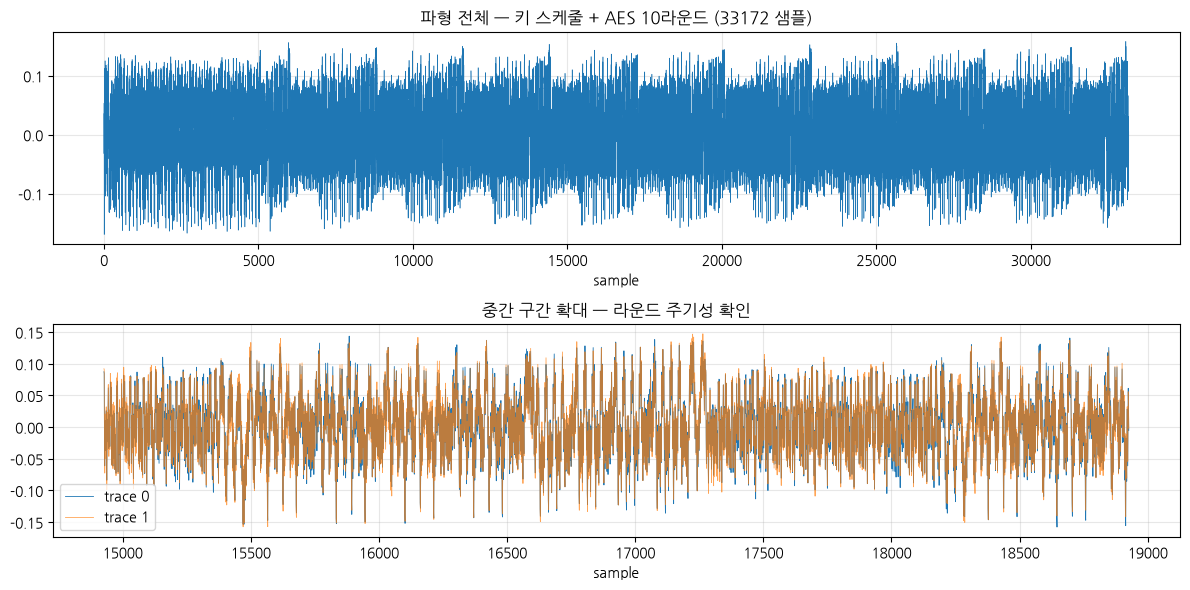

타겟 사이클 환산: 33172 샘플 / adc_mul 4 = 8293 사이클


In [11]:
if not OUT_PATH.is_file():
    print("데이터셋이 없다. §8 을 먼저 실행한다.")
else:
    with h5py.File(OUT_PATH, "r") as h5:
        print("=== attrs ===")
        for k in sorted(h5.attrs):
            v = h5.attrs[k]
            print("  %-14s %s" % (k, v))
        print()
        print("=== 그룹 ===")
        for name in h5:
            g = h5[name]
            print("  /%-10s i_k%s i_p%s o%s t%s %s"
                  % (name, g["i_k"].shape, g["i_p"].shape, g["o"].shape,
                     g["t"].shape, g["t"].dtype))
        ns = int(h5.attrs["ns"])
        adc_mul = int(h5.attrs["adc_mul"])
        w0 = h5["explore/t"][0].astype(np.float64) / h5.attrs["trace_scale"]
        w1 = h5["explore/t"][1].astype(np.float64) / h5.attrs["trace_scale"]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    axes[0].plot(w0, lw=0.4)
    axes[0].set_title("파형 전체 — 키 스케줄 + AES 10라운드 (%d 샘플)" % ns)
    axes[0].set_xlabel("sample")

    # 뒷부분을 확대하면 라운드 반복 구조가 눈에 들어온다.
    s0 = int(ns * 0.45)
    axes[1].plot(range(s0, s0 + min(4000, ns - s0)), w0[s0:s0 + 4000], lw=0.6, label="trace 0")
    axes[1].plot(range(s0, s0 + min(4000, ns - s0)), w1[s0:s0 + 4000], lw=0.6, alpha=0.7, label="trace 1")
    axes[1].set_title("중간 구간 확대 — 라운드 주기성 확인")
    axes[1].set_xlabel("sample")
    axes[1].legend()
    for ax in axes:
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    print("타겟 사이클 환산: %d 샘플 / adc_mul %d = %.0f 사이클"
          % (ns, adc_mul, ns / adc_mul))

---
## 10. 자원 해제

USB·시리얼을 반환한다. 이 셀을 건너뛰면 다음 실행에서 장치를 못 여는 일이 생긴다.

In [12]:
def disconnect_all(scopes_dict, target_obj):
    try:
        target_obj.dis()
        print("[OK] target.dis()")
    except Exception as e:
        print("[WARN] target.dis():", e)
    for name, sc in list(scopes_dict.items()):
        try:
            sc.dis()
            print("[OK] %s.dis()" % name)
        except Exception as e:
            print("[WARN] %s.dis(): %s" % (name, e))
    scopes_dict.clear()


disconnect_all(scopes, target)
print("완료.")

[OK] target.dis()
[OK] ChipWhisperer_Husky.dis()
[OK] ChipWhisperer_Lite.dis()
완료.


---
## 11. 요약

| 항목 | 내용 |
|------|------|
| 타겟 | tiny-AES-c AES-128 **ECB** 한 블록 (`AES_init_ctx` + `AES_ECB_encrypt`) |
| 트리거 범위 | AES 연산 **전체** — 펌웨어가 `MY_AES_ECB()` 를 `trigger_high/low` 로 감쌈 |
| 파형 길이 | 상수가 아니라 `scope.adc.trig_count` 로 결정 |
| 샘플링 | 타겟 클럭 × `adc_mul=2` |
| 저장 | `traces/scalib_dataset.h5`, 그룹별 `i_k`/`i_p`/`o`/`t`, `t` 는 ADC 코드 스케일 `int16` |
| 무결성 | 매 트레이스 골든 AES 대조. 완주 = 무결성 증거 |

### 실패 시 점검

1. `cw.list_devices()` 에 Lite·Husky 가 모두 보이는가.
2. 골든 AES 가 일치하는가 (플래시·`len=16`).
3. Husky PLL lock 실패 → AUX 클럭 배선과 진폭.
4. capture 타임아웃 → TRIG(D0) 배선, 펌웨어 트리거.
5. §7 의 진폭 최댓값이 0.5 에 가까우면 클리핑이다 → `GAIN_DB` 를 낮춘다.
6. `trig_count` 가 매번 다르면 트리거·클럭이 불안정한 것이다.

다음: `1.0.SNR.ipynb` 로 누설 지점을 찾는다.